# 02 - Pre-processamento e Splits

**O notebook mais critico do fluxo.** Produz, de uma vez so, os dados que todos os
notebooks de modelo consomem.

**Saidas:** `data/processed/{train,val,test}.parquet`, `split_meta.json`

> A vetorizacao TF-IDF **nao** acontece aqui. Ela e ajustada dentro do pipeline de cada
> modelo, apenas no split de treino. Vetorizar antes do split vazaria estatistica do
> conjunto de teste para dentro do vocabulario.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Carregamento

In [2]:
from src.data.loader import load_raw

raw = load_raw()
print(f"Documentos brutos: {len(raw):,}")

Documentos brutos: 14,438


## 2. Mapeamento categoria -> urgencia

> **Regra heuristica, nao validada clinicamente.** O corpus rotula condicao medica; a
> urgencia e derivada por regra declarada em `configs/model_config.yaml`. Isso precisa
> estar dito no README, no Model Card e no video.

Linhas cuja categoria nao tem mapeamento sao **descartadas**, nunca jogadas numa classe
padrao silenciosamente.

In [3]:
from src.data.preprocessing import map_urgency

print("Mapeamento configurado:")
for categoria, urgencia in CONFIG["urgency_mapping"].items():
    print(f"  {categoria} -> {urgencia}")

mapeado = map_urgency(raw)
descartados = len(raw) - len(mapeado)
print(f"\nDocumentos mapeados: {len(mapeado):,}")
print(f"Descartados (categoria sem mapeamento): {descartados:,}")

Mapeamento configurado:
  1 -> atencao
  2 -> normal
  3 -> atencao
  4 -> urgente
  5 -> normal

Documentos mapeados: 14,438
Descartados (categoria sem mapeamento): 0


## 3. Limpeza

Normaliza espacos, remove textos curtos demais e duplicatas.

In [4]:
from src.data.preprocessing import class_distribution, drop_degenerate

limpo = drop_degenerate(mapeado)
print(f"Apos limpeza: {len(limpo):,} ({len(mapeado) - len(limpo):,} removidos)")
display(class_distribution(limpo))

Apos limpeza: 11,227 (3,211 removidos)


,n,proporcao
urgencia,,
atencao,4102,0.3654
normal,4642,0.4135
urgente,2483,0.2212


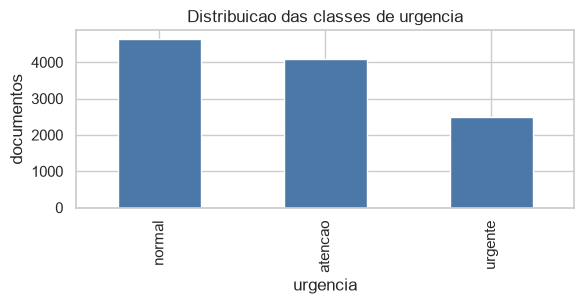

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ordem = CONFIG["classes"]
limpo["urgencia"].value_counts().reindex(ordem).plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Distribuicao das classes de urgencia")
ax.set_ylabel("documentos")
plt.tight_layout()
plt.show()

> Se a distribuicao estiver desbalanceada, isso confirma a escolha de **F1-macro** como
> metrica de promocao: a acuracia premiaria um modelo que ignora a classe minoritaria,
> que aqui e justamente a que importa.

## 4. Splits estratificados

70/15/15, `random_state` fixo, estratificado por urgencia.

In [6]:
from src.data.preprocessing import make_splits

splits = make_splits(limpo)
resumo = pd.DataFrame({
    nome: class_distribution(df)["proporcao"] for nome, df in splits.items()
})
print({nome: len(df) for nome, df in splits.items()})
display(resumo)

{'train': 7858, 'val': 1684, 'test': 1685}


,train,val,test
urgencia,,,
atencao,0.3654,0.3652,0.3656
normal,0.4135,0.4133,0.4136
urgente,0.2212,0.2215,0.2208


> As proporcoes por classe devem ser praticamente identicas entre os tres splits. Se nao forem, a estratificacao falhou.

## 5. Persistencia e metadados

In [7]:
import json

from src.config import DATA_PROCESSED, DATA_RAW
from src.data.loader import dataset_hash

for nome, df in splits.items():
    df.to_parquet(DATA_PROCESSED / f"{nome}.parquet", index=False)
    print(f"{nome:6s} -> {len(df):,} documentos")

meta = {
    "seed": SEED,
    "proporcoes": CONFIG["split"],
    "n_por_split": {nome: int(len(df)) for nome, df in splits.items()},
    "distribuicao_por_split": {
        nome: class_distribution(df)["n"].to_dict() for nome, df in splits.items()
    },
    "urgency_mapping": CONFIG["urgency_mapping"],
    "hash_arquivos_brutos": {p.name: dataset_hash(p) for p in sorted(DATA_RAW.glob("*.csv"))},
}
with (DATA_PROCESSED / "split_meta.json").open("w", encoding="utf-8") as handle:
    json.dump(meta, handle, indent=2, ensure_ascii=False, default=str)
print("\nsplit_meta.json salvo")

train  -> 7,858 documentos
val    -> 1,684 documentos
test   -> 1,685 documentos

split_meta.json salvo


---

> A partir daqui, **nenhum notebook regenera splits.** Os modelos leem estes arquivos.
> Se os splits mudarem, todos os modelos precisam ser retreinados para que a comparacao
> continue valida.